Data Points: 982
Intercept (b): 2.3107
Coefficient (m): -0.0344
R-squared: 0.0032


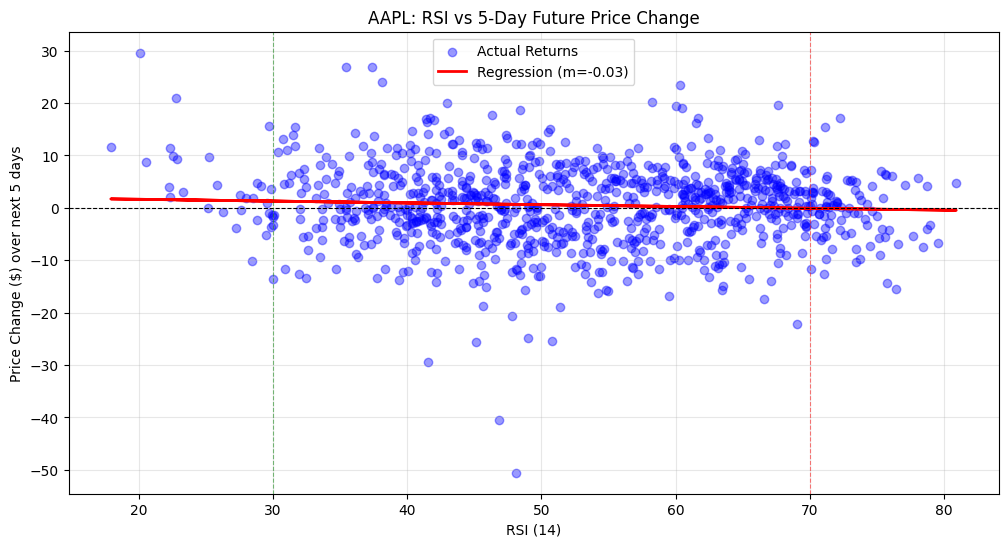

In [1]:
# Import standard packages
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Import scikit-learn for regression analysis
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Global variables
ticker = 'AAPL'                 # Example stock ticker
lookback = 1000                 # Lookback period for data (number of days)
interval = '1d'                 # Data interval (daily)
shift = 5                       # Number of days to shift for target variable

def get_data(ticker, lookback, interval):
    # auto_adjust=True ensures we get 'Close' without MultiIndex issues
    df = yf.download(ticker, period=f"{lookback}d", interval=interval, progress=False, auto_adjust=True)
    
    # Handle MultiIndex columns if they occur (common in new yfinance versions)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        
    df = df.reset_index()
    return df

def calculate_rsi(df, window=14):
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    # Use Exponential Moving Average (Wilder's Smoothing) for standard RSI
    # Note: com (Center of Mass) = window - 1 is standard for RSI
    avg_gain = gain.ewm(com=window-1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window-1, min_periods=window).mean()
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    df['RSI'] = rsi
    return df

def main():
    # 1. Load data
    df = get_data(ticker, lookback, interval)

    # 2. Calculate RSI
    df = calculate_rsi(df)

    # 3. Create target: Future price change (Close in 'shift' days - Today's Close)
    df[f'Close_plus_{shift}'] = df['Close'].shift(-shift)
    df['target'] = df[f'Close_plus_{shift}'] - df['Close']

    # 4. Clean data (drop NaNs from RSI lookback and Shift lookforward)
    df = df.dropna(subset=['RSI', 'target'])

    # 5. Prepare Regression
    X = df['RSI'].values.reshape(-1, 1)  # Feature
    y = df['target'].values              # Target

    # 6. Fit Model
    model = LinearRegression()
    model.fit(X, y)

    # 7. Metrics & Output
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    print(f"Data Points: {len(df)}")
    print(f"Intercept (b): {model.intercept_:.4f}")
    print(f"Coefficient (m): {model.coef_[0]:.4f}")
    print(f"R-squared: {r2:.4f}")

    # 8. Plot
    plt.figure(figsize=(12, 6))
    plt.scatter(df['RSI'], df['target'], alpha=0.4, label='Actual Returns', color='blue')
    plt.plot(df['RSI'], y_pred, color='red', linewidth=2, label=f'Regression (m={model.coef_[0]:.2f})')
    
    plt.title(f'{ticker}: RSI vs {shift}-Day Future Price Change')
    plt.xlabel('RSI (14)')
    plt.ylabel(f'Price Change ($) over next {shift} days')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Zero line
    plt.axvline(30, color='green', linestyle='--', linewidth=0.8, alpha=0.5) # RSI OS
    plt.axvline(70, color='red', linestyle='--', linewidth=0.8, alpha=0.5)   # RSI OB
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    main()

Total Strategy Return: 40.71%
Market Return:         128.11%


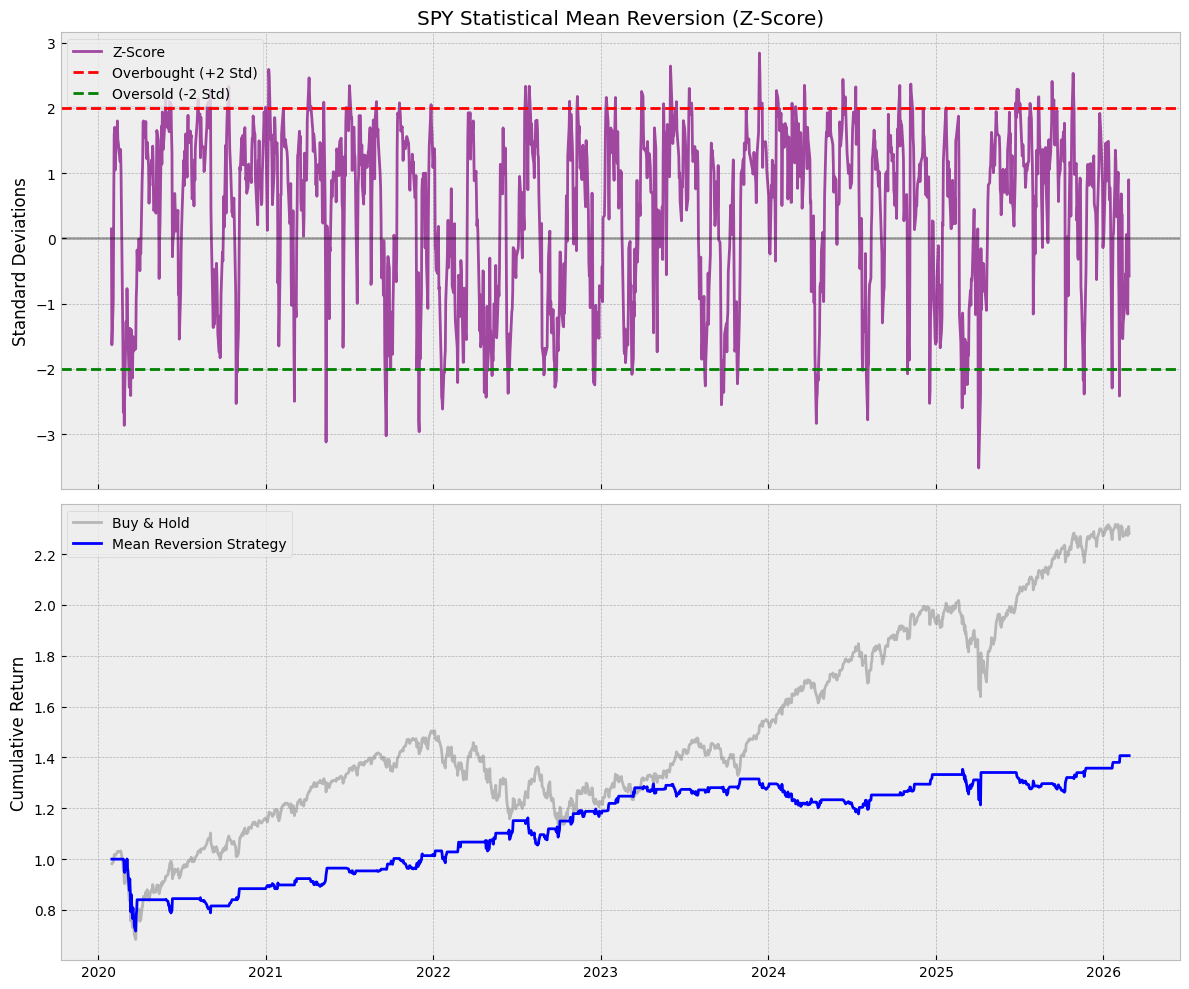

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
TICKER = 'SPY'
START_DATE = '2020-01-01'
WINDOW = 20           # Lookback window (like Bollinger Bands standard)
Z_THRESH = 2.0        # Entry Threshold (2 Standard Deviations)
EXIT_Z = 0.5          # Exit Threshold (Close trade when price returns near mean)

def get_data(ticker):
    """Fetch and clean data"""
    df = yf.download(ticker, start=START_DATE, progress=False, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

def calculate_stats(df, window):
    """Calculate Z-Score based on Rolling Mean and Std Dev"""
    # 1. Rolling Mean (The 'Fair Value')
    df['mean'] = df['Close'].rolling(window=window).mean()
    
    # 2. Rolling Std Dev (Volatility)
    df['std'] = df['Close'].rolling(window=window).std()
    
    # 3. Z-Score (Distance from mean in units of Sigma)
    df['z_score'] = (df['Close'] - df['mean']) / df['std']
    
    return df.dropna()

def generate_signals(df):
    """Generate Buy/Sell signals based on Z-Score thresholds"""
    df['position'] = 0  # 0 = Flat, 1 = Long, -1 = Short
    
    # Using numpy select for vectorization (faster than loops)
    # This logic creates a simple state machine
    conditions = [
        (df['z_score'] < -Z_THRESH), # Buy Signal (Oversold)
        (df['z_score'] > Z_THRESH),  # Sell Signal (Overbought)
        (abs(df['z_score']) < EXIT_Z) # Exit Signal (Reverted to mean)
    ]
    
    # 1 = Enter Long, -1 = Enter Short, 0 = Exit
    choices = [1, -1, 0]
    
    # This is a raw signal; real trading requires state management (holding positions)
    # We forward-fill the position to simulate holding until an exit signal
    signal = np.select(conditions, choices, default=np.nan)
    df['signal'] = signal
    df['position'] = df['signal'].ffill().fillna(0)
    
    return df

def backtest(df):
    """Calculate returns"""
    # Calculate daily returns of the asset
    df['market_return'] = df['Close'].pct_change()
    
    # Strategy return = Position (yesterday) * Market Return (today)
    df['strategy_return'] = df['position'].shift(1) * df['market_return']
    
    # Cumulative returns
    df['cum_market'] = (1 + df['market_return']).cumprod()
    df['cum_strategy'] = (1 + df['strategy_return']).cumprod()
    
    return df

def plot_results(df, ticker):
    """Visualizes Z-Score and Equity Curve"""
    plt.style.use('bmh') # Clean quant style
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # Plot 1: Z-Score
    ax1.plot(df.index, df['z_score'], label='Z-Score', color='purple', alpha=0.7)
    ax1.axhline(Z_THRESH, color='red', linestyle='--', label='Overbought (+2 Std)')
    ax1.axhline(-Z_THRESH, color='green', linestyle='--', label='Oversold (-2 Std)')
    ax1.axhline(0, color='black', alpha=0.3)
    ax1.set_title(f'{ticker} Statistical Mean Reversion (Z-Score)')
    ax1.set_ylabel('Standard Deviations')
    ax1.legend(loc='upper left')

    # Plot 2: Performance
    ax2.plot(df.index, df['cum_market'], label='Buy & Hold', color='gray', alpha=0.5)
    ax2.plot(df.index, df['cum_strategy'], label='Mean Reversion Strategy', color='blue')
    ax2.set_ylabel('Cumulative Return')
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    data = get_data(TICKER)
    data = calculate_stats(data, WINDOW)
    data = generate_signals(data)
    results = backtest(data)
    
    # Print Summary Stats
    total_return = results['cum_strategy'].iloc[-1] - 1
    print(f"Total Strategy Return: {total_return:.2%}")
    print(f"Market Return:         {results['cum_market'].iloc[-1] - 1:.2%}")
    
    plot_results(results, TICKER)